# Cluster-Based undersampling Method.
This notebook implements and tries a Cluster based undersampling methodology to handle imabalnce in large datasets.

Link: https://www.sciencedirect.com/science/article/pii/S1877050923016101?ref=pdf_download&fr=RR-2&rr=9ee72d739db6000e

While it is not the exact implementation, the below work mimics it as close as possible by following the pipeline/steps.
1) Normalize the data
2) Run K-means and Pick the Best K via Silhouette Coefficient
3) For each cluster:

    - If homogeneous majority: flag samples within a distance threshold from the centroid
    - If inhomogeneous: use KNN to find k of the majority-class neighbors of minority samples and flag them  

4) Remove all flagged samples and reverse normalization                                                     

In [1]:
# Libraries needed.....

import pandas as pd
import numpy as np

# Train & Test splitting
from sklearn.model_selection import train_test_split

# Normalize that data/Standerdizing 
from sklearn.preprocessing import StandardScaler # Done use this for now
from sklearn.preprocessing import MinMaxScaler

# K-means
from sklearn.cluster import KMeans

# Silhouette Coefficient
from sklearn.metrics import silhouette_score

# Nearest Neighbour
from sklearn.neighbors import NearestNeighbors

# TSNE for visual
from sklearn.manifold import TSNE


In [2]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------

# Functions:

In [3]:
# Finds the most optimal distance (parameter) for a point from the centroid:

def optimal_dist_param(distances, n_ranges=5, percentage=0.7):
    #array of distances from each sample to its centroid
    #n_ranges    : number of distance buckets to create (default 5) as mentioned in the paper
    #percentage  : target fraction of samples to remove (default 0.7) as mentioned in the paper
    if len(distances) == 0:
        return 0.0
 
    max_dist = distances.max()
    if max_dist == 0:
        return 0.0
 
    # Normalize distances to [0, 1]
    norm_distances = distances / max_dist
 
    # Split [0,1] into n_ranges equal buckets and count samples per bucket
    bins = np.linspace(0, 1, n_ranges + 1)
    counts, _ = np.histogram(norm_distances, bins=bins)
    total = len(distances)
 
    # Find the bucket whose cumulative proportion sits in [percentage, percentage+0.1]
    cumulative = 0.0
    for i, count in enumerate(counts):
        cumulative += count / total
        if percentage <= cumulative <= percentage + 0.1:
            return bins[i + 1]   # upper edge of this bucket is the threshold
 
    # Return the fixed default
    return percentage

In [4]:
# Finds and returns the most optimal number of clusters

def find_optimal_k(X, k_min=20, k_max=30, random_state=42):
    # X : dataset
    # k_min : minimum clusters to try (default 20)
    # k_max : maximum clusters to try (default 30)
    
    best_k = k_min
    best_score = -1.0
 
    # Cap k_max so we never request more clusters than samples
    k_max = min(k_max, len(X) - 1)
 
    print(f"Evaluating k from {k_min} to {k_max}...")
 
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X)
 
        # Silhouette requires a minimum 2 distinct cluster labels
        if len(np.unique(labels)) < 2:
            continue
 
        score = silhouette_score(X, labels)
        if score > best_score:
            best_score = score
            best_k = k
 
    print(f"Best k={best_k} (silhouette={best_score:.4f})")
    return best_k

## Main Class:

CLEANSE- Cluster Based Undersampling Method

Link to paper: https://www.sciencedirect.com/science/article/pii/S1877050923016101?ref=pdf_download&fr=RR-2&rr=9ee72d739db6000e



In [5]:
class CLEANSE:
 
    def __init__(self, distance='auto', inhomo=True, k_neighbors=6, k_min=20, k_max=30, majority_label=0, minority_label=1, random_state=42):
        self.distance = distance
        self.inhomo = inhomo
        self.k_neighbors = k_neighbors
        self.k_min = k_min
        self.k_max = k_max
        self.majority_label = majority_label
        self.minority_label = minority_label
        self.random_state = random_state
 
        self.scaler_ = None
        self.kmeans_ = None
        self.n_removed_ = 0
 
    
    def _normalize(self, X):
        # Normalizing the data
        self.scaler_ = MinMaxScaler()
        return self.scaler_.fit_transform(X)
 
    def _denormalize(self, X_scaled):
        # Reversing the normalization
        return self.scaler_.inverse_transform(X_scaled)

    # Process a Homogeneous Majority Cluster
    # Removes samples closest to the centroid.
    def _process_homogeneous_majority(self, cluster_indices, X_scaled, centroid):
        
        # Logic: compute each sample's distance to the centroid,
        # then remove those within [distance threshold * max_dist].
        # Closest-to-center = most redundant = safe to remove.
        
        X_cluster = X_scaled[cluster_indices]
        distances = np.linalg.norm(X_cluster - centroid, axis=1)
 
        # Determine distance threshold
        if self.distance == 'auto':
            dist_param = optimal_dist_param(distances)
        else:
            dist_param = self.distance   # can be provided by user
 
        max_dist = distances.max()
        threshold = dist_param * max_dist
 
        # Flag samples within threshold distance from centroid
        to_remove = set()
        for i, (idx, dist) in enumerate(zip(cluster_indices, distances)):
            if dist <= threshold:
                to_remove.add(idx)
 
        return to_remove
 
    # Process an Inhomogeneous (Mixed) Cluster
    # Removes majority samples that are nearest neighbors of minority samples.
    # These boundary-hugging legitimate claims blur the fraud decision boundary.
    def _process_inhomogeneous(self, cluster_indices, X_scaled, y):
        # Flag majority samples that are k-nearest neighbors of minority samples.
 
        # Logic: for each fraud sample in the cluster, find its k nearest. By default it is set up as 6. 
        # legitimate-claim neighbors. Those are the ambiguous boundary points that hurt classifier performance, remove them.
 
        to_remove = set()
 
        cluster_mask = np.array(cluster_indices)
        y_cluster = y[cluster_mask]
 
        minority_mask = y_cluster == self.minority_label
        majority_mask = y_cluster == self.majority_label
 
        minority_indices = cluster_mask[minority_mask]
        majority_indices = cluster_mask[majority_mask]
 
        # Ensuring that is atleast 1 entry of each class
        if len(minority_indices) == 0 or len(majority_indices) == 0:
            return to_remove
 
        X_majority = X_scaled[majority_indices]
        X_minority = X_scaled[minority_indices]
 
        # Fit KNN on majority samples only
        k = min(self.k_neighbors, len(majority_indices))
        nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean')
        nbrs.fit(X_majority)
 
        # For each fraud sample, find its k nearest legitimate neighbors
        _, neighbor_positions = nbrs.kneighbors(X_minority)
 
        # Flag those majority neighbors for removal
        # Note: all flagging happens before any removal so order doesn't matter
        for positions in neighbor_positions:
            for pos in positions:
                to_remove.add(majority_indices[pos])
 
        return to_remove
 
    # Main fit_resample Entry Point
    def fit_resample(self, X, y):
        # Main Function to run
 
        # Ensures provided data are DataFrames
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, pd.Series):
            y = y.values
 
        X = np.array(X, dtype=float)
        y = np.array(y)
 
        n_majority = np.sum(y == self.majority_label)
        n_minority = np.sum(y == self.minority_label)
        print(f"\n")
        print(f"CLEANSE Undersampling")
        print(f"{'-'*60}")
        print(f"Input  | Total: {len(y)} | Legit: {n_majority} | Fraud: {n_minority}")
        print(f"Config | distance={self.distance} | inhomo={self.inhomo} | k_neighbors={self.k_neighbors}")
 
        
        # Normalize the data
        print(f"\n--- Normalizing features (MinMax) ---")
        X_scaled = self._normalize(X)
        print(f"  Done. All features scaled to [0, 1].")
 
        # Find optimal K vlaue
        print(f"\n--- Finding optimal number of clusters ---")
        best_k = find_optimal_k(
            X_scaled,
            k_min=self.k_min,
            k_max=self.k_max,
            random_state=self.random_state
        )
 
        
        # K-means clustering + per-cluster processing
        print(f"\n--- Running K-means (k={best_k}) and processing clusters ---")
        self.kmeans_ = KMeans(n_clusters=best_k, random_state=self.random_state, n_init=10)
        cluster_labels = self.kmeans_.fit_predict(X_scaled)
        centroids = self.kmeans_.cluster_centers_
 
        all_flagged = set()
        cluster_summary = []
 
        for cluster_id in range(best_k):
            cluster_indices = np.where(cluster_labels == cluster_id)[0]
            y_in_cluster = y[cluster_indices]
 
            has_majority = np.any(y_in_cluster == self.majority_label)
            has_minority = np.any(y_in_cluster == self.minority_label)
 
            # Classify the cluster type
            if not has_majority and has_minority:
                # Pure fraud cluster, keep
                cluster_type = "homogeneous_minority"
                flagged = set()
 
            elif has_majority and not has_minority:
                # Pure legitimate cluster, remove
                cluster_type = "homogeneous_majority"
                flagged = self._process_homogeneous_majority(
                    cluster_indices, X_scaled, centroids[cluster_id]
                )
 
            else:
                # Mixed cluster, flag k points close to the points that are fraud
                cluster_type = "inhomogeneous"
                if self.inhomo:
                    flagged = self._process_inhomogeneous(
                        cluster_indices, X_scaled, y
                    )
                else:
                    flagged = set()
 
            all_flagged.update(flagged)
            cluster_summary.append({
                'cluster': cluster_id,
                'type': cluster_type,
                'total': len(cluster_indices),
                'legit': int(np.sum(y_in_cluster == self.majority_label)),
                'fraud': int(np.sum(y_in_cluster == self.minority_label)),
                'flagged_for_removal': len(flagged)
            })
 
        # Print cluster summary
        print(f"\n  {'Cluster':<10} {'Type':<25} {'Total':<8} {'Legit':<8} {'Fraud':<8} {'Removed':<8}")
        print(f"  {'-'*70}")
        for s in cluster_summary:
            print(f"  {s['cluster']:<10} {s['type']:<25} {s['total']:<8} {s['legit']:<8} {s['fraud']:<8} {s['flagged_for_removal']:<8}")
 
        
        # Remove flagged samples
        
        print(f"\n--- Removing flagged samples ---")
        keep_mask = np.ones(len(y), dtype=bool)
        keep_mask[list(all_flagged)] = False
 
        X_kept = X_scaled[keep_mask]
        y_kept = y[keep_mask]
 
        
        # Reverse normalization
        print(f"--- Reversing normalization ---")
        X_resampled = self._denormalize(X_kept)
        y_resampled = y_kept
 
        
        # Quick Summary
        self.n_removed_ = int(all_flagged.__len__())
        n_maj_out = int(np.sum(y_resampled == self.majority_label))
        n_min_out = int(np.sum(y_resampled == self.minority_label))
        ir_before = n_majority / n_minority if n_minority > 0 else float('inf')
        ir_after  = n_maj_out  / n_min_out  if n_min_out  > 0 else float('inf')
 
        print(f"\n")
        print(f"CLEANSE Complete")
        print(f"{'-'*60}")
        print(f"Samples removed  : {self.n_removed_}")
        print(f"Output | Total: {len(y_resampled)} | Legit: {n_maj_out} | Fraud: {n_min_out}")
        print(f"Imbalance ratio  : {ir_before:.2f}  →  {ir_after:.2f}")
        print(f"{'='*60}\n")
        
        # Store the indices for the groupkfold
        self.sample_indices_ = np.where(keep_mask)[0]
 
        return X_resampled, y_resampled

In [6]:
if __name__ == "__main__":

    print('Hello there!\nKindly refer the "How will this be used" portion of the notebook to run the pipeline. That being said, this cell can be used for testing purposes.')
    print('\nTesting to be done below the line.\n')
    print('-'*150)

Hello there!
Kindly refer the "How will this be used" portion of the notebook to run the pipeline. That being said, this cell can be used for testing purposes.

Testing to be done below the line.

------------------------------------------------------------------------------------------------------------------------------------------------------


In [24]:
## Extra: Visual

def plot_cleanse_clusters(cleanse, X, y, X_resampled, y_resampled, output_dir="."):
    from sklearn.manifold import TSNE

    # Convert to numpy
    X_np = X.values if isinstance(X, pd.DataFrame) else X.copy()
    y_np = y.values if isinstance(y, pd.Series)    else y.copy()

    # Normalize using the same scaler from fit_resample
    X_scaled = cleanse.scaler_.transform(X_np.astype(float))

    # ── Kept / removed mask ──────────────────────────────────────────────────
    # Use the stored indices from the already-fitted cleanse object
    removed_mask = np.ones(len(y_np), dtype=bool)
    removed_mask[cleanse.sample_indices_] = False   # kept → False

    # ── Cluster assignments & types ──────────────────────────────────────────
    cluster_labels = cleanse.kmeans_.predict(X_scaled)

    cluster_types = {}
    for cluster_id in range(cleanse.kmeans_.n_clusters):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        y_in_cluster    = y_np[cluster_indices]
        has_majority    = np.any(y_in_cluster == cleanse.majority_label)
        has_minority    = np.any(y_in_cluster == cleanse.minority_label)
        if has_majority and not has_minority:
            cluster_types[cluster_id] = "homogeneous_majority"
        elif has_minority and not has_majority:
            cluster_types[cluster_id] = "homogeneous_minority"
        else:
            cluster_types[cluster_id] = "inhomogeneous"

    sample_cluster_type = np.array([cluster_types[c] for c in cluster_labels])

    # ── Optional t-SNE downsampling ──────────────────────────────────────────
    MAX_TSNE = 8000
    if len(X_scaled) > MAX_TSNE:
        print(f"Sampling {MAX_TSNE} points for t-SNE...")
        rng          = np.random.default_rng(cleanse.random_state)
        minority_idx = np.where(y_np == cleanse.minority_label)[0]
        majority_idx = np.where(y_np == cleanse.majority_label)[0]
        majority_sample = rng.choice(
            majority_idx,
            size=min(MAX_TSNE - len(minority_idx), len(majority_idx)),
            replace=False,
        )
        sample_idx = np.concatenate([minority_idx, majority_sample])
    else:
        sample_idx = np.arange(len(X_scaled))

    # ── t-SNE ────────────────────────────────────────────────────────────────
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, random_state=cleanse.random_state,
                perplexity=30, max_iter=500)
    X_2d = tsne.fit_transform(X_scaled[sample_idx])

    y_sample       = y_np[sample_idx]
    removed_sample = removed_mask[sample_idx]

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))

    # 1. Majority kept — blue dots
    mask = (~removed_sample) & (y_sample == cleanse.majority_label)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c="steelblue", alpha=0.3, s=10, label="Majority (kept)")

    # 2. Removed samples — green crosses
    mask = removed_sample
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c="green", alpha=0.7, s=15, marker="x", label="Removed")

    # 3. Minority kept — red dots on top
    mask = (~removed_sample) & (y_sample == cleanse.minority_label)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c="red", s=50, zorder=5, label="Minority (kept)",
               edgecolors="darkred", linewidths=0.5)

    ax.set_title("CLEANSE - t-SNE Cluster Map", fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, markerscale=1.8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()

    path = os.path.join(output_dir, "cleanse_tsne.png")
    plt.savefig(path, dpi=500)
    plt.show()
    

## Example

In [8]:
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset.csv")

target_col = 'target'

exclude_cols = [
    'npi', 'rfrg_prvdr_state_abrvtn',
    'specialty_type', 'specialty'
]

# df.head(5)
len(df.columns)

216

In [9]:
print(df.dtypes[df.dtypes == 'object'])

rfrg_prvdr_state_abrvtn    object
specialty_type             object
specialty                  object
dtype: object


In [10]:
columns = df.columns.tolist()
for col in exclude_cols:
    if col in columns:
        df = df.drop(columns=col)


In [11]:
y = df[target_col]
X = df.loc[:,df.columns!=target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, stratify = y, random_state = 42)

In [12]:
cleanse = CLEANSE(
        distance='auto',    
        inhomo=True,        
        k_neighbors=6,      
        k_min=20,
        k_max=30)

In [13]:
X_resampled, y_resampled = cleanse.fit_resample(X_train, y_train)

print(f"Number of row before undersampling: {X_train.shape[0]}\n")
print(f"Number of row after undersampling: {X_resampled.shape[0]}\n")



CLEANSE Undersampling
------------------------------------------------------------
Input  | Total: 84496 | Legit: 84462 | Fraud: 34
Config | distance=auto | inhomo=True | k_neighbors=6

--- Normalizing features (MinMax) ---
  Done. All features scaled to [0, 1].

--- Finding optimal number of clusters ---
Evaluating k from 20 to 30...
Best k=20 (silhouette=0.0987)

--- Running K-means (k=20) and processing clusters ---

  Cluster    Type                      Total    Legit    Fraud    Removed 
  ----------------------------------------------------------------------
  0          inhomogeneous             4961     4959     2        12      
  1          homogeneous_majority      999      999      0        950     
  2          inhomogeneous             4116     4115     1        6       
  3          inhomogeneous             7149     7146     3        18      
  4          homogeneous_majority      7355     7355     0        7134    
  5          inhomogeneous             1540     153

Sampling 8000 points for t-SNE...
Running t-SNE...


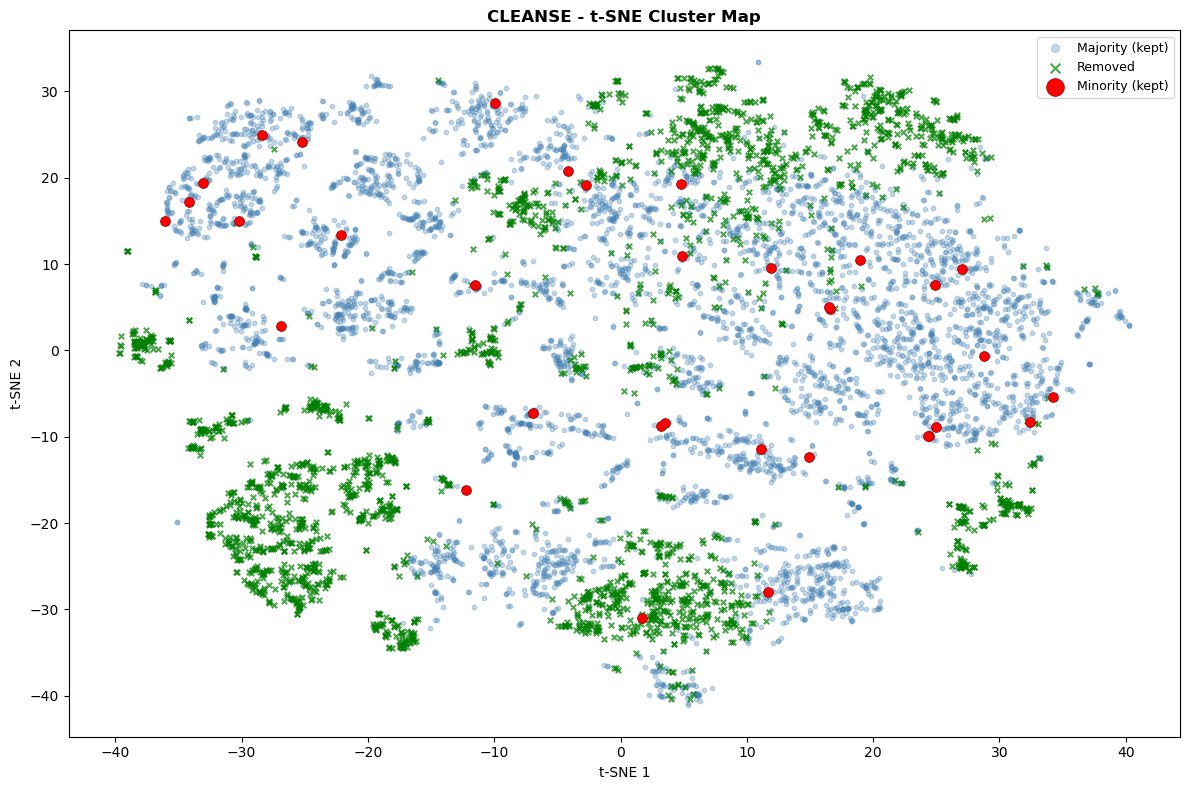

In [25]:
import matplotlib.pyplot as plt
import os
plot_cleanse_clusters(cleanse, X_train, y_train, X_resampled, y_resampled)

## Observations:

This cluster based undersampling method removes data from the majority class by making several informed decision based on the structure of the data. In short it doesnt randomly remove data from the majority class, and in turn, preserves the most important information for the classifier. 

The tradeoff is computational cost over simplicity, it significantly slower than any of the other methods present but the samples retained, on paper, are more meaningful.

Regardless, from testing that have been condcuted we find these values to be suitable for the method:
1) k_neighbors=6 
2) k_min=20
3) k_max=22 (Reducing the time it takes to find the best as well)